# GlobalTech Corp × AcquiredCo — HR Integration EDA Report
**Purpose:** Exploratory analysis and visualisation of the unified golden employee dataset produced by the HR data integration pipeline.

Run `main.py` first to generate the golden dataset before executing this notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT = Path().resolve().parent
OUTPUT_DIR = ROOT / 'output'
GOLDEN_PATH = OUTPUT_DIR / 'golden_dataset.parquet'
VALIDATION_PATH = OUTPUT_DIR / 'reports' / 'validation_report.csv'

PALETTE = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})


def _src(ax, dy=-0.08):
    ax.annotate('Source: HR Integration Pipeline', xy=(.01, dy), xycoords='axes fraction',
                fontsize=8, color='#888', style='italic')

def _barh(ax, series, title, xlabel='Employee Count', ylabel='', fs=None, dy=-0.08, **tkw):
    bars = ax.barh(series.index, series.values,
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(series))], edgecolor='white')
    for b, v in zip(bars, series.values):
        ax.text(b.get_width() + .5, b.get_y() + b.get_height() / 2, f'{v:,}', va='center', fontsize=fs)
    ax.set_title(title, fontweight='bold', **tkw); ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.spines[['top', 'right']].set_visible(False); _src(ax, dy)

def _enroll_barh(ax, rate, title, fs=None, **tkw):
    bars = ax.barh(rate.index, rate.values * 100,
                   color=[PALETTE[0] if r < 0.5 else PALETTE[2] for r in rate.values], edgecolor='white')
    for b, v in zip(bars, rate.values):
        ax.text(b.get_width() + .5, b.get_y() + b.get_height() / 2, f'{v:.0%}', va='center', fontsize=fs)
    ax.set(xlim=(0, 115), xlabel='Enrollment Rate (%)', ylabel='Department')
    ax.set_title(title, fontweight='bold', **tkw)
    ax.legend(handles=[mpatches.Patch(color=PALETTE[0], label='< 50%'),
                       mpatches.Patch(color=PALETTE[2], label='≥ 50%')])
    ax.spines[['top', 'right']].set_visible(False); _src(ax)

def _quality_bar(ax, vr, dy=-0.12, **tkw):
    x, w = np.arange(len(vr)), 0.35
    ax.bar(x - w/2, vr['passed'], w, label='Passed', color=PALETTE[2], alpha=.85, edgecolor='white')
    ax.bar(x + w/2, vr['failed'],  w, label='Failed',  color=PALETTE[5], alpha=.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_', '\n', 1) for c in vr['check']], fontsize=7, rotation=45, ha='right')
    ax.set(ylabel='Record Count', xlabel='Quality Check')
    ax.set_title('Data Quality Summary — Passed vs Failed per Check', fontweight='bold', **tkw)
    ax.legend(); ax.spines[['top', 'right']].set_visible(False); _src(ax, dy)

In [2]:
df = pd.read_parquet(GOLDEN_PATH)
print(f'Golden dataset: {len(df):,} records, {df.shape[1]} columns')

Golden dataset: 9,140 records, 30 columns


In [3]:
validation_report = pd.read_csv(VALIDATION_PATH) if VALIDATION_PATH.exists() else pd.DataFrame()
validation_report

,check,description,total,passed,failed,pass_rate,status,severity
0,NOT_NULL_EMPLOYEE_ID,'employee_id' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
1,NOT_NULL_FIRST_NAME,'first_name' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
2,NOT_NULL_LAST_NAME,'last_name' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
3,NOT_NULL_EMAIL,'email' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
4,NOT_NULL_DEPARTMENT_CANONICAL,'department_canonical' must not be null,9140,9125,15,0.9984,PASS,CRITICAL
5,NOT_NULL_COUNTRY,'country' must not be null,9140,9136,4,0.9996,PASS,CRITICAL
6,UNIQUE_EMAIL,'email' must be unique,9140,9140,0,1.0000,PASS,CRITICAL
7,UNIQUE_EMPLOYEE_ID,'employee_id' must be unique,9140,9140,0,1.0000,PASS,CRITICAL
8,IN_SET_EMPLOYMENT_TYPE,"'employment_type' in ['Contractor', 'Full-Time...",9140,9140,0,1.0000,PASS,CRITICAL
9,IN_SET_SALARY_CURRENCY,"'salary_currency' in ['EUR', 'GBP', 'USD']",9140,9140,0,1.0000,PASS,WARNING


## Chart 1 — Headcount by Department

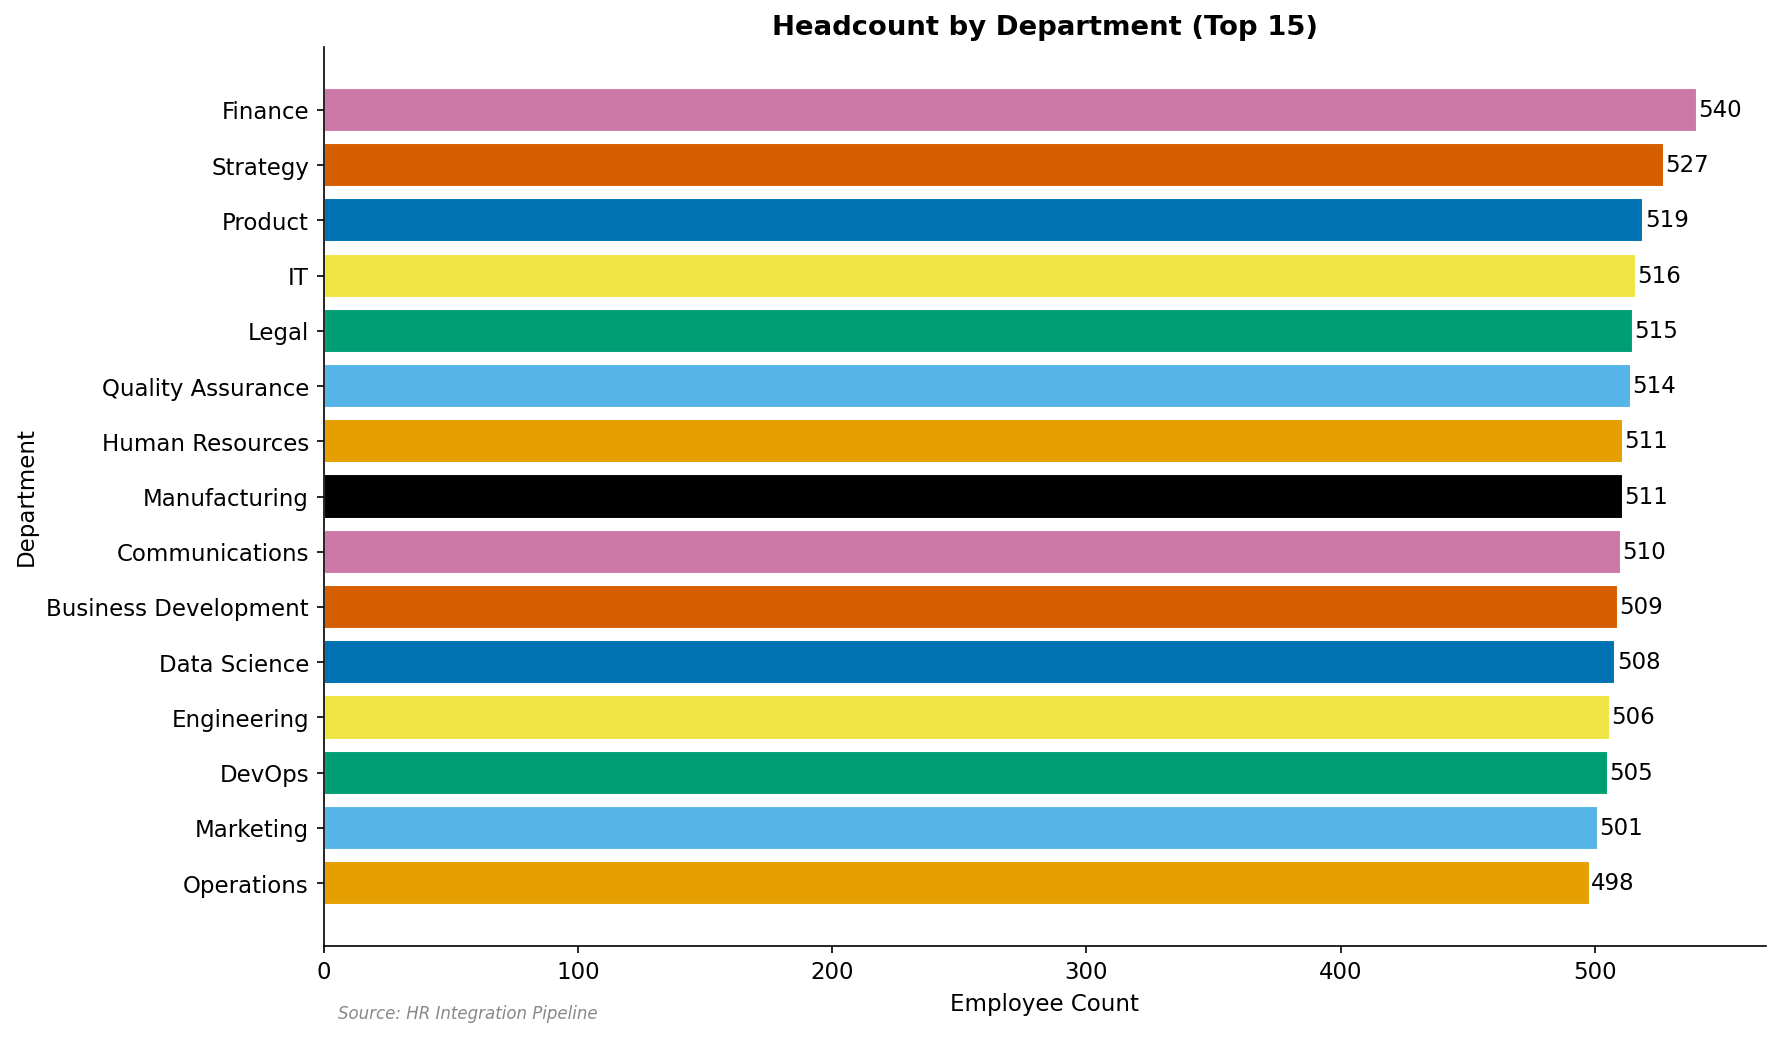

In [4]:
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'
counts = df[dept_col].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(12, 7))
_barh(ax, counts, 'Headcount by Department (Top 15)', ylabel='Department')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_headcount_by_dept.png', dpi=300, bbox_inches='tight'); plt.show()

## Chart 2 — Headcount by Country

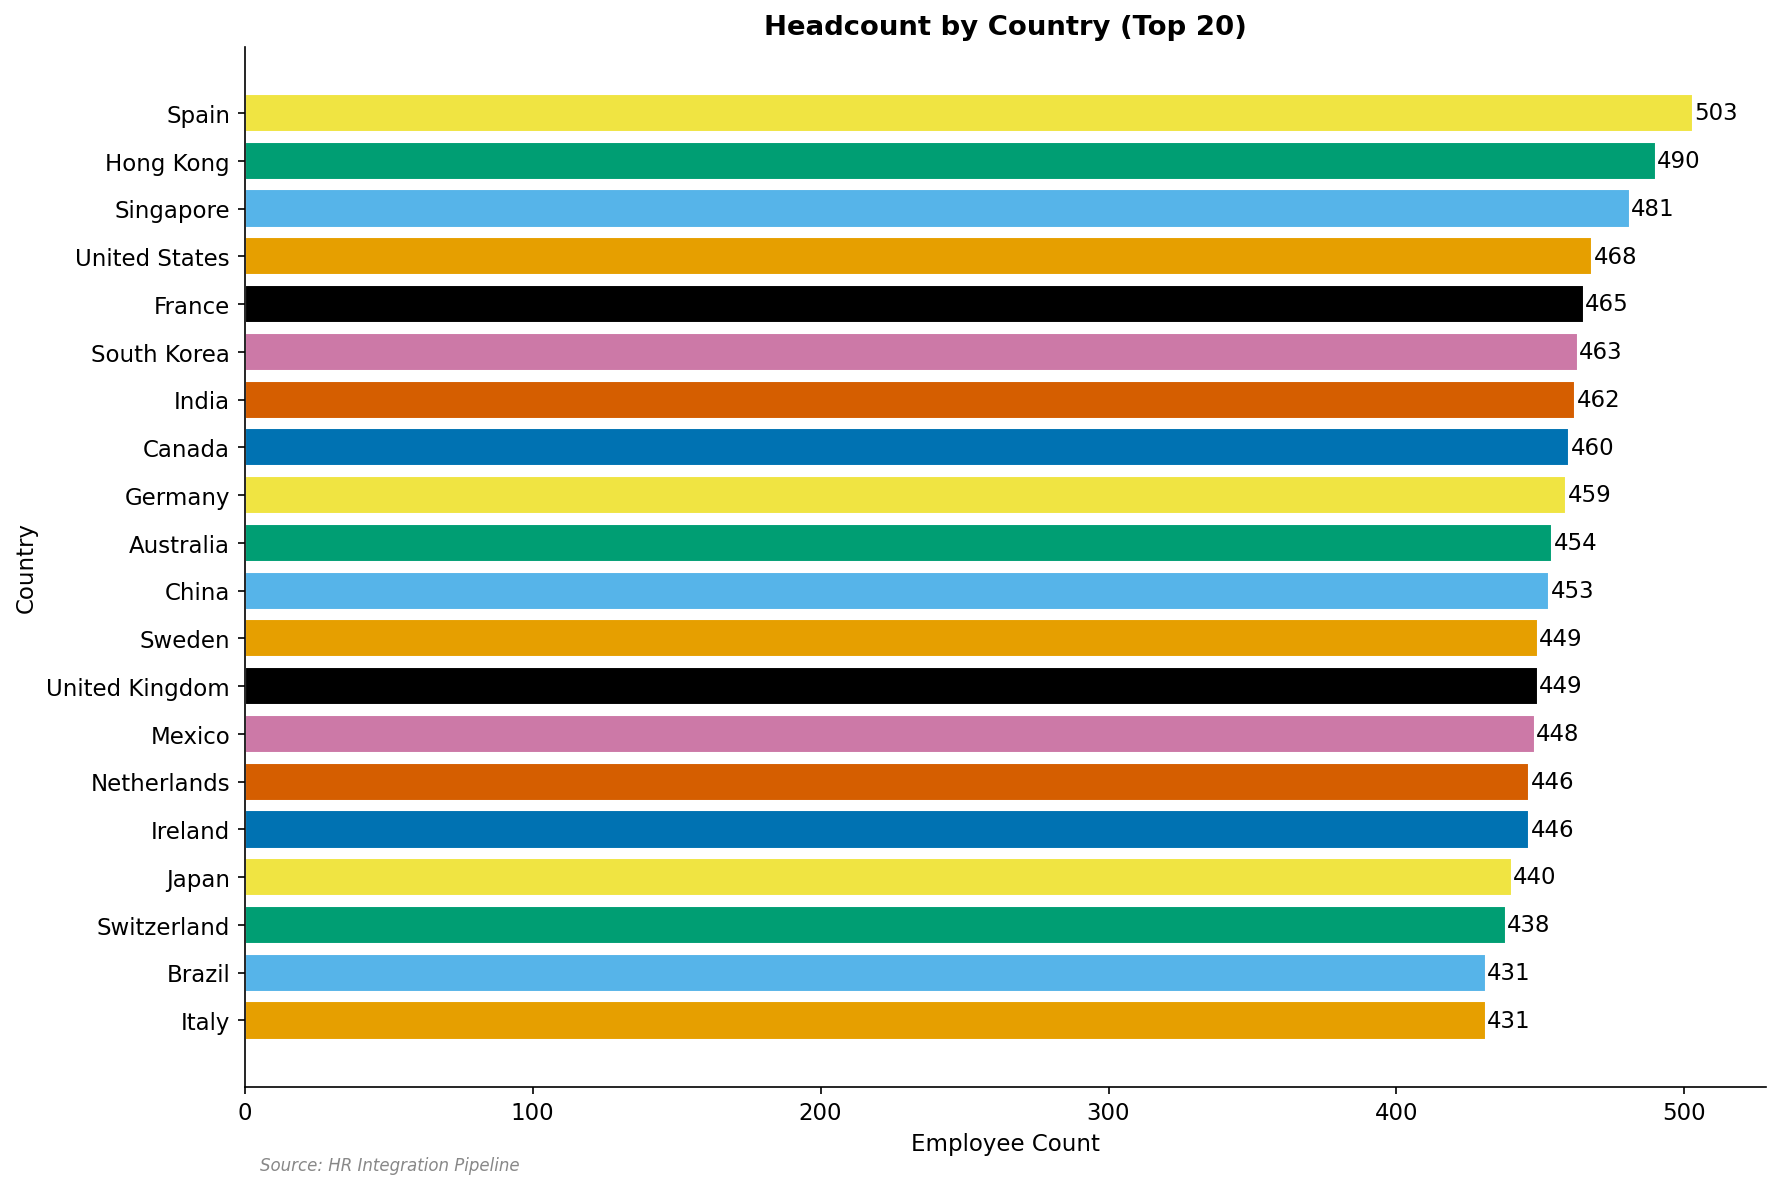

In [5]:
counts = df['country'].value_counts().head(20).sort_values()
fig, ax = plt.subplots(figsize=(12, 8))
_barh(ax, counts, 'Headcount by Country (Top 20)', ylabel='Country')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_headcount_by_country.png', dpi=300, bbox_inches='tight'); plt.show()

## Chart 3 — Salary Distribution by Employment Type

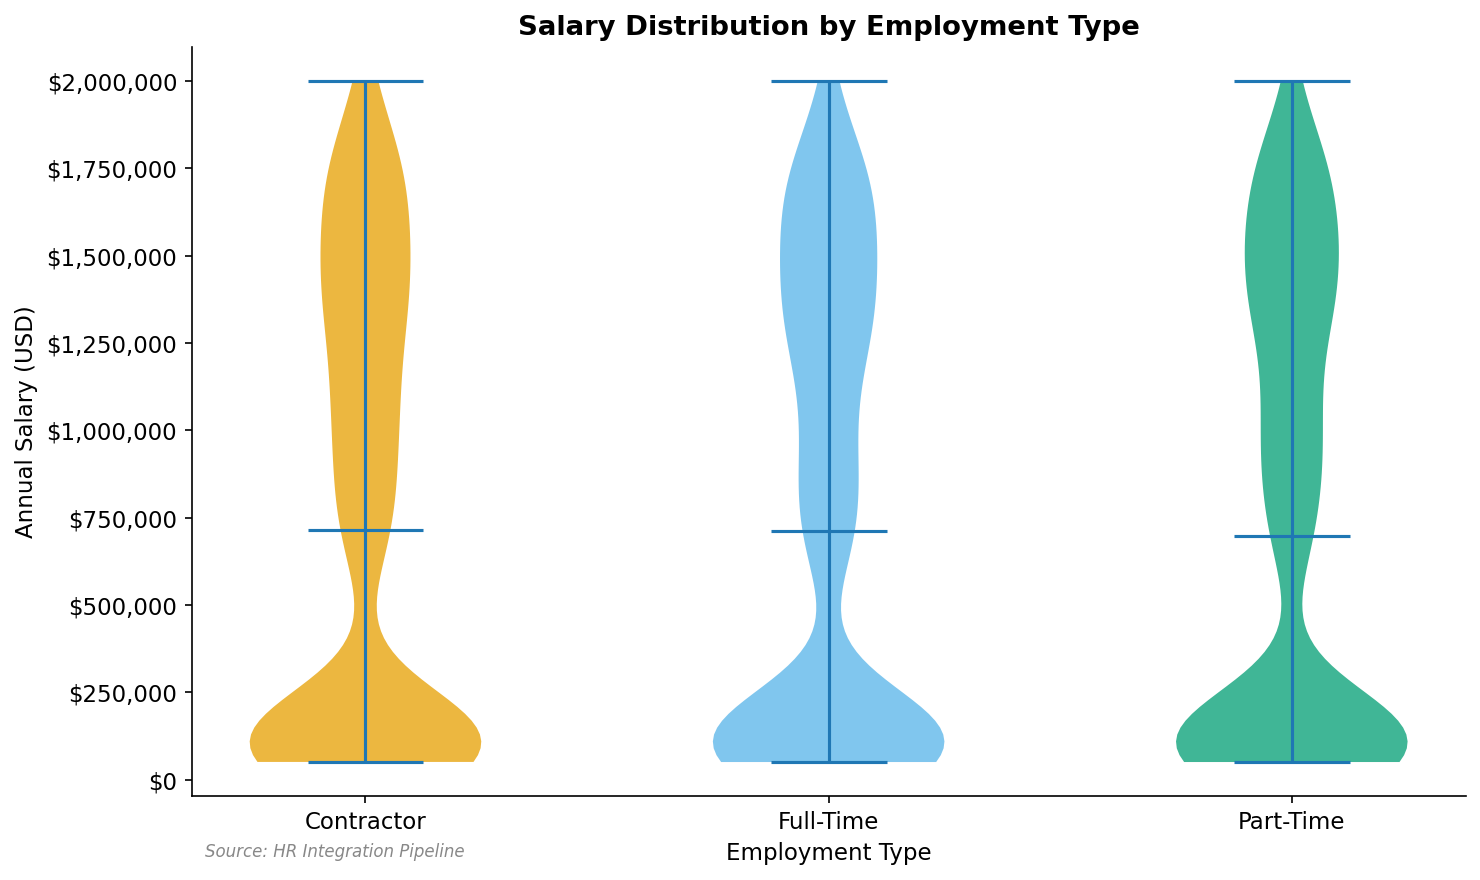

In [6]:
plot_df = df[['employment_type', 'salary_usd_annual']].dropna()
types = sorted(plot_df['employment_type'].dropna().unique())
data = [plot_df.loc[plot_df['employment_type'] == t, 'salary_usd_annual'].values for t in types]
fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, positions=range(len(types)), showmedians=True)
for i, pc in enumerate(parts['bodies']): pc.set_facecolor(PALETTE[i % len(PALETTE)]); pc.set_alpha(0.75)
ax.set_xticks(range(len(types))); ax.set_xticklabels(types)
ax.set(ylabel='Annual Salary (USD)', xlabel='Employment Type')
ax.set_title('Salary Distribution by Employment Type', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False); _src(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_salary_distribution.png', dpi=300, bbox_inches='tight'); plt.show()

## Chart 4 — Tenure Distribution

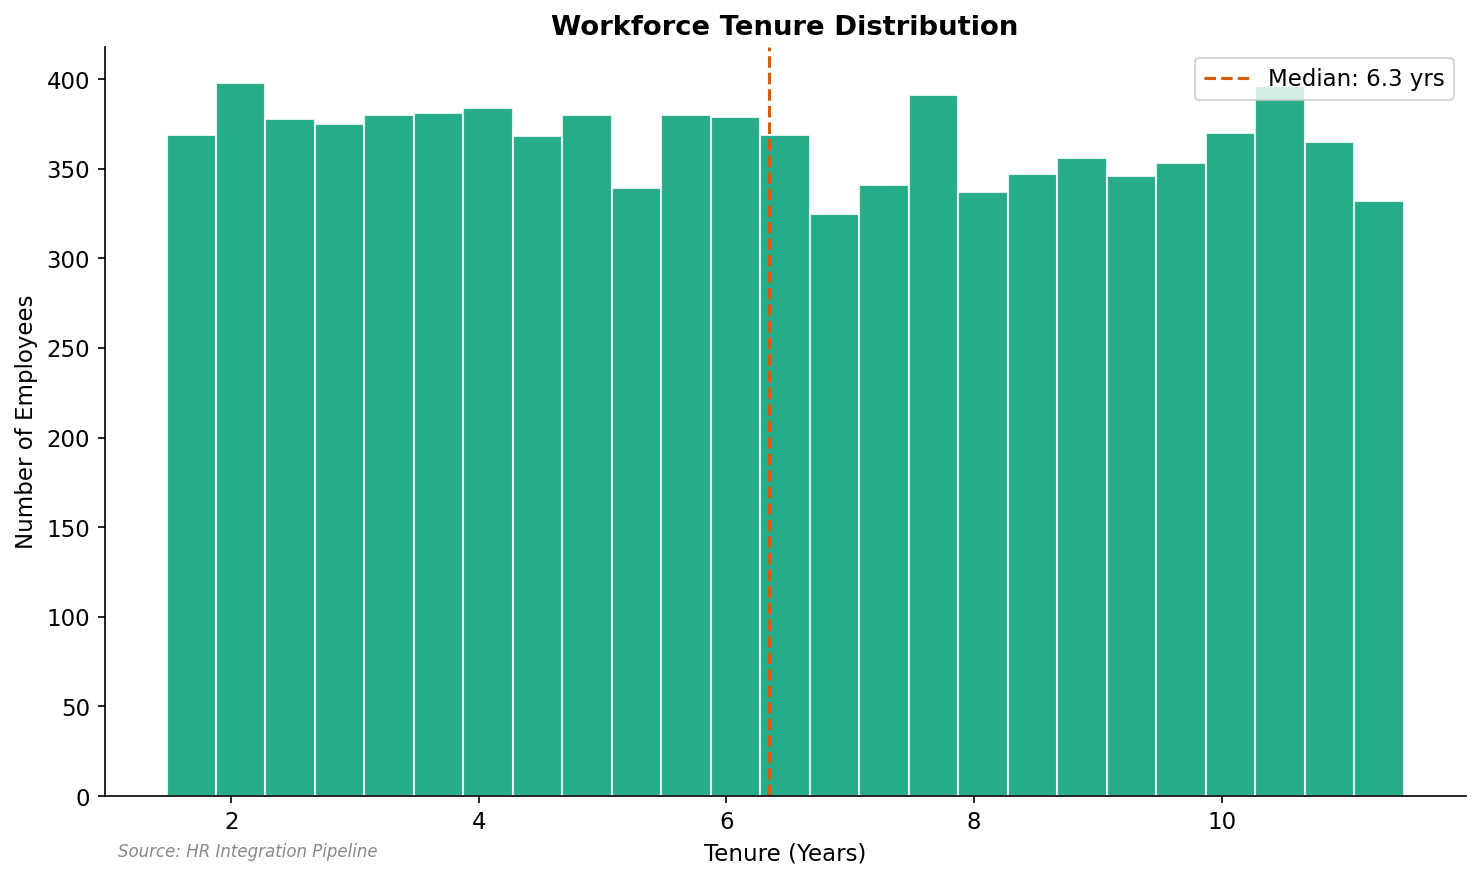

In [7]:
tenure = ((pd.Timestamp.today() - pd.to_datetime(df['hire_date'], errors='coerce')).dt.days / 365.25).dropna().clip(lower=0)
median = tenure.median()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(tenure, bins=25, color=PALETTE[2], edgecolor='white', alpha=0.85)
ax.axvline(median, color=PALETTE[5], linestyle='--', linewidth=1.5, label=f'Median: {median:.1f} yrs')
ax.legend(); ax.set(xlabel='Tenure (Years)', ylabel='Number of Employees')
ax.set_title('Workforce Tenure Distribution', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False); _src(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart4_tenure_distribution.png', dpi=300, bbox_inches='tight'); plt.show()

## Chart 5 — Benefits Enrollment Rate by Department

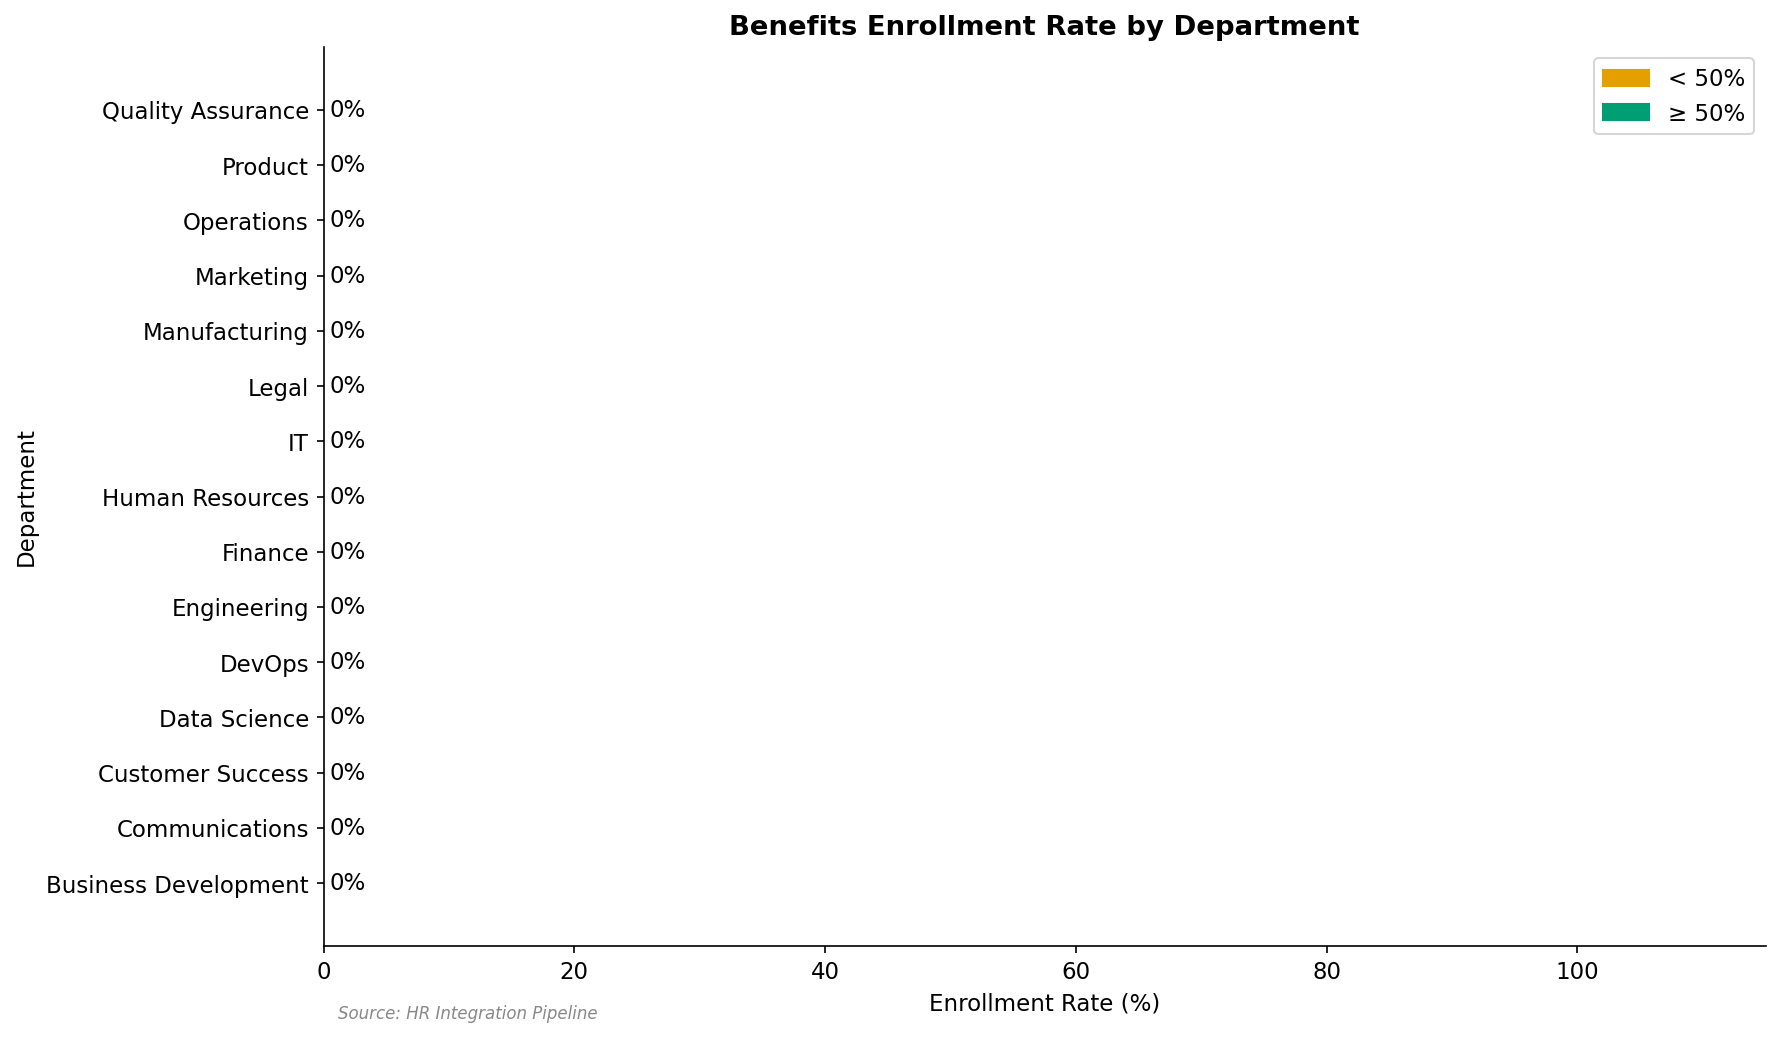

In [8]:
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'
plot_df = df[[dept_col, 'benefits_enrolled']].dropna(subset=[dept_col]).copy()
plot_df['benefits_enrolled'] = plot_df['benefits_enrolled'].astype(bool)
rate = plot_df.groupby(dept_col)['benefits_enrolled'].mean().sort_values().head(15)
fig, ax = plt.subplots(figsize=(12, 7))
_enroll_barh(ax, rate, 'Benefits Enrollment Rate by Department')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart5_benefits_enrollment.png', dpi=300, bbox_inches='tight'); plt.show()

## Chart 6 — Data Quality Summary (Pipeline Health Dashboard)

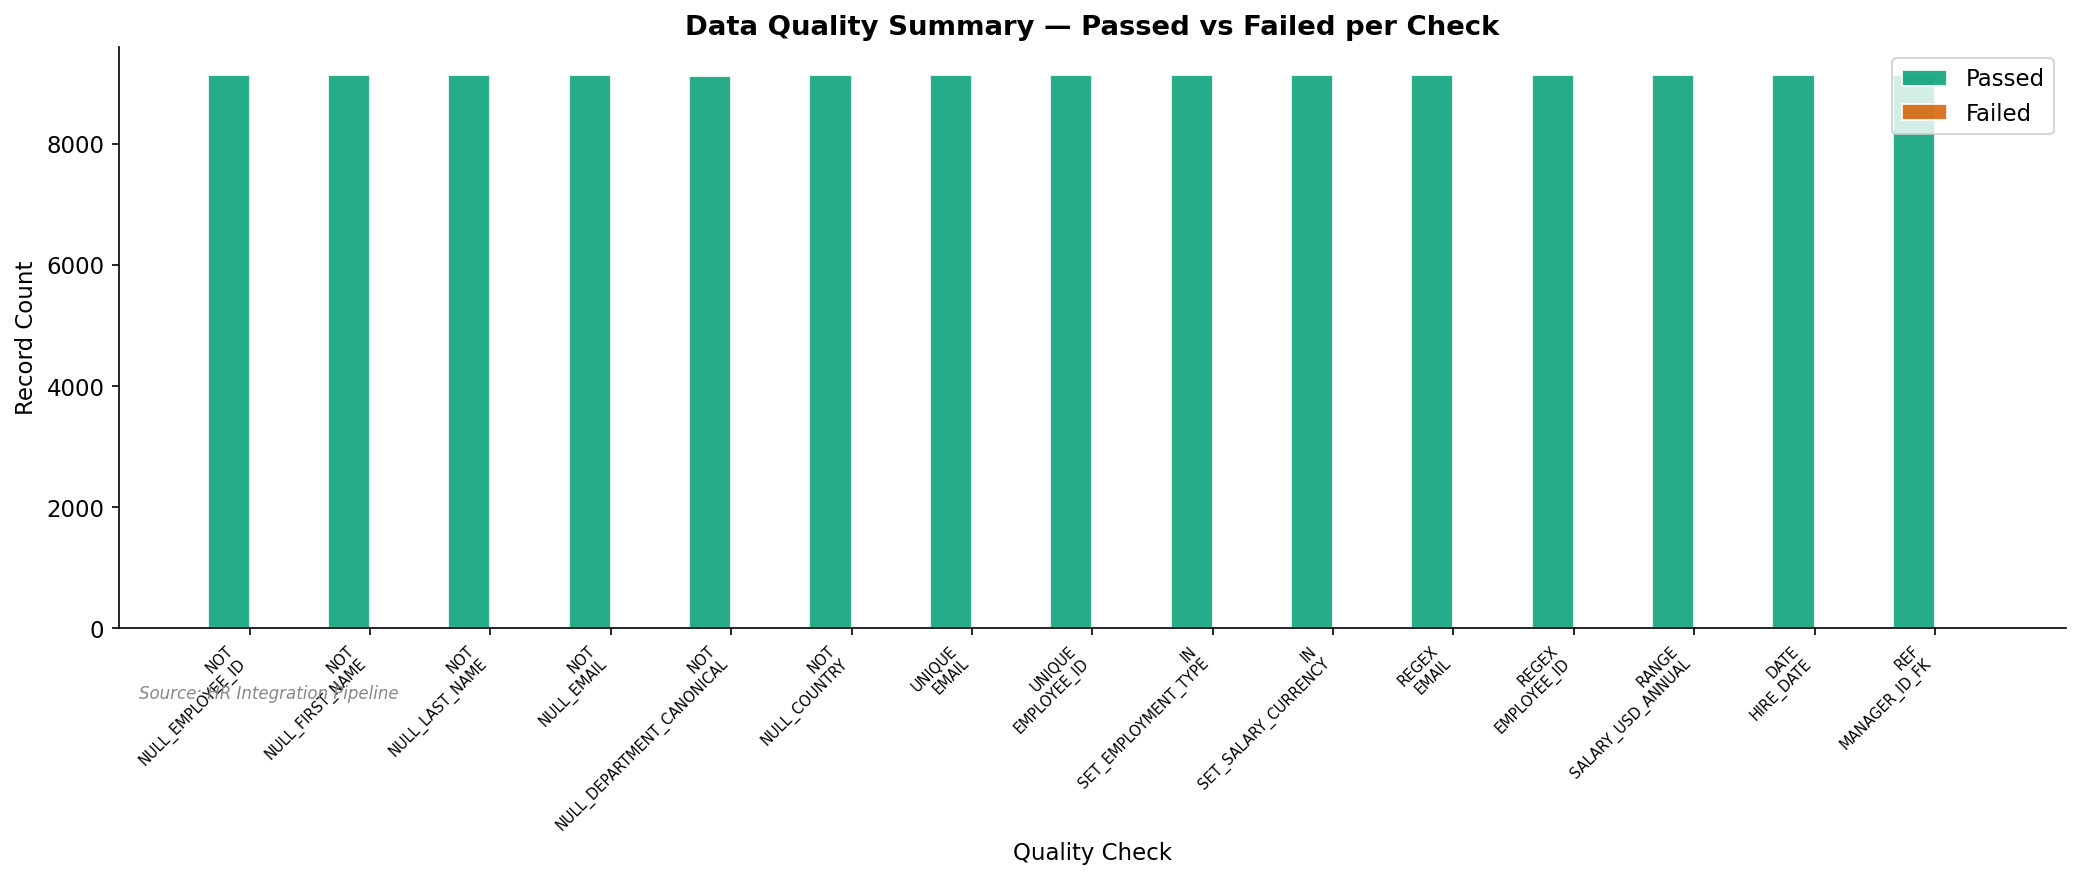

In [9]:
if validation_report.empty:
    print('No validation report found. Run main.py first.')
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    _quality_bar(ax, validation_report)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart6_data_quality.png', dpi=300, bbox_inches='tight'); plt.show()

## Combined Multi-Panel Report (300 DPI PNG)

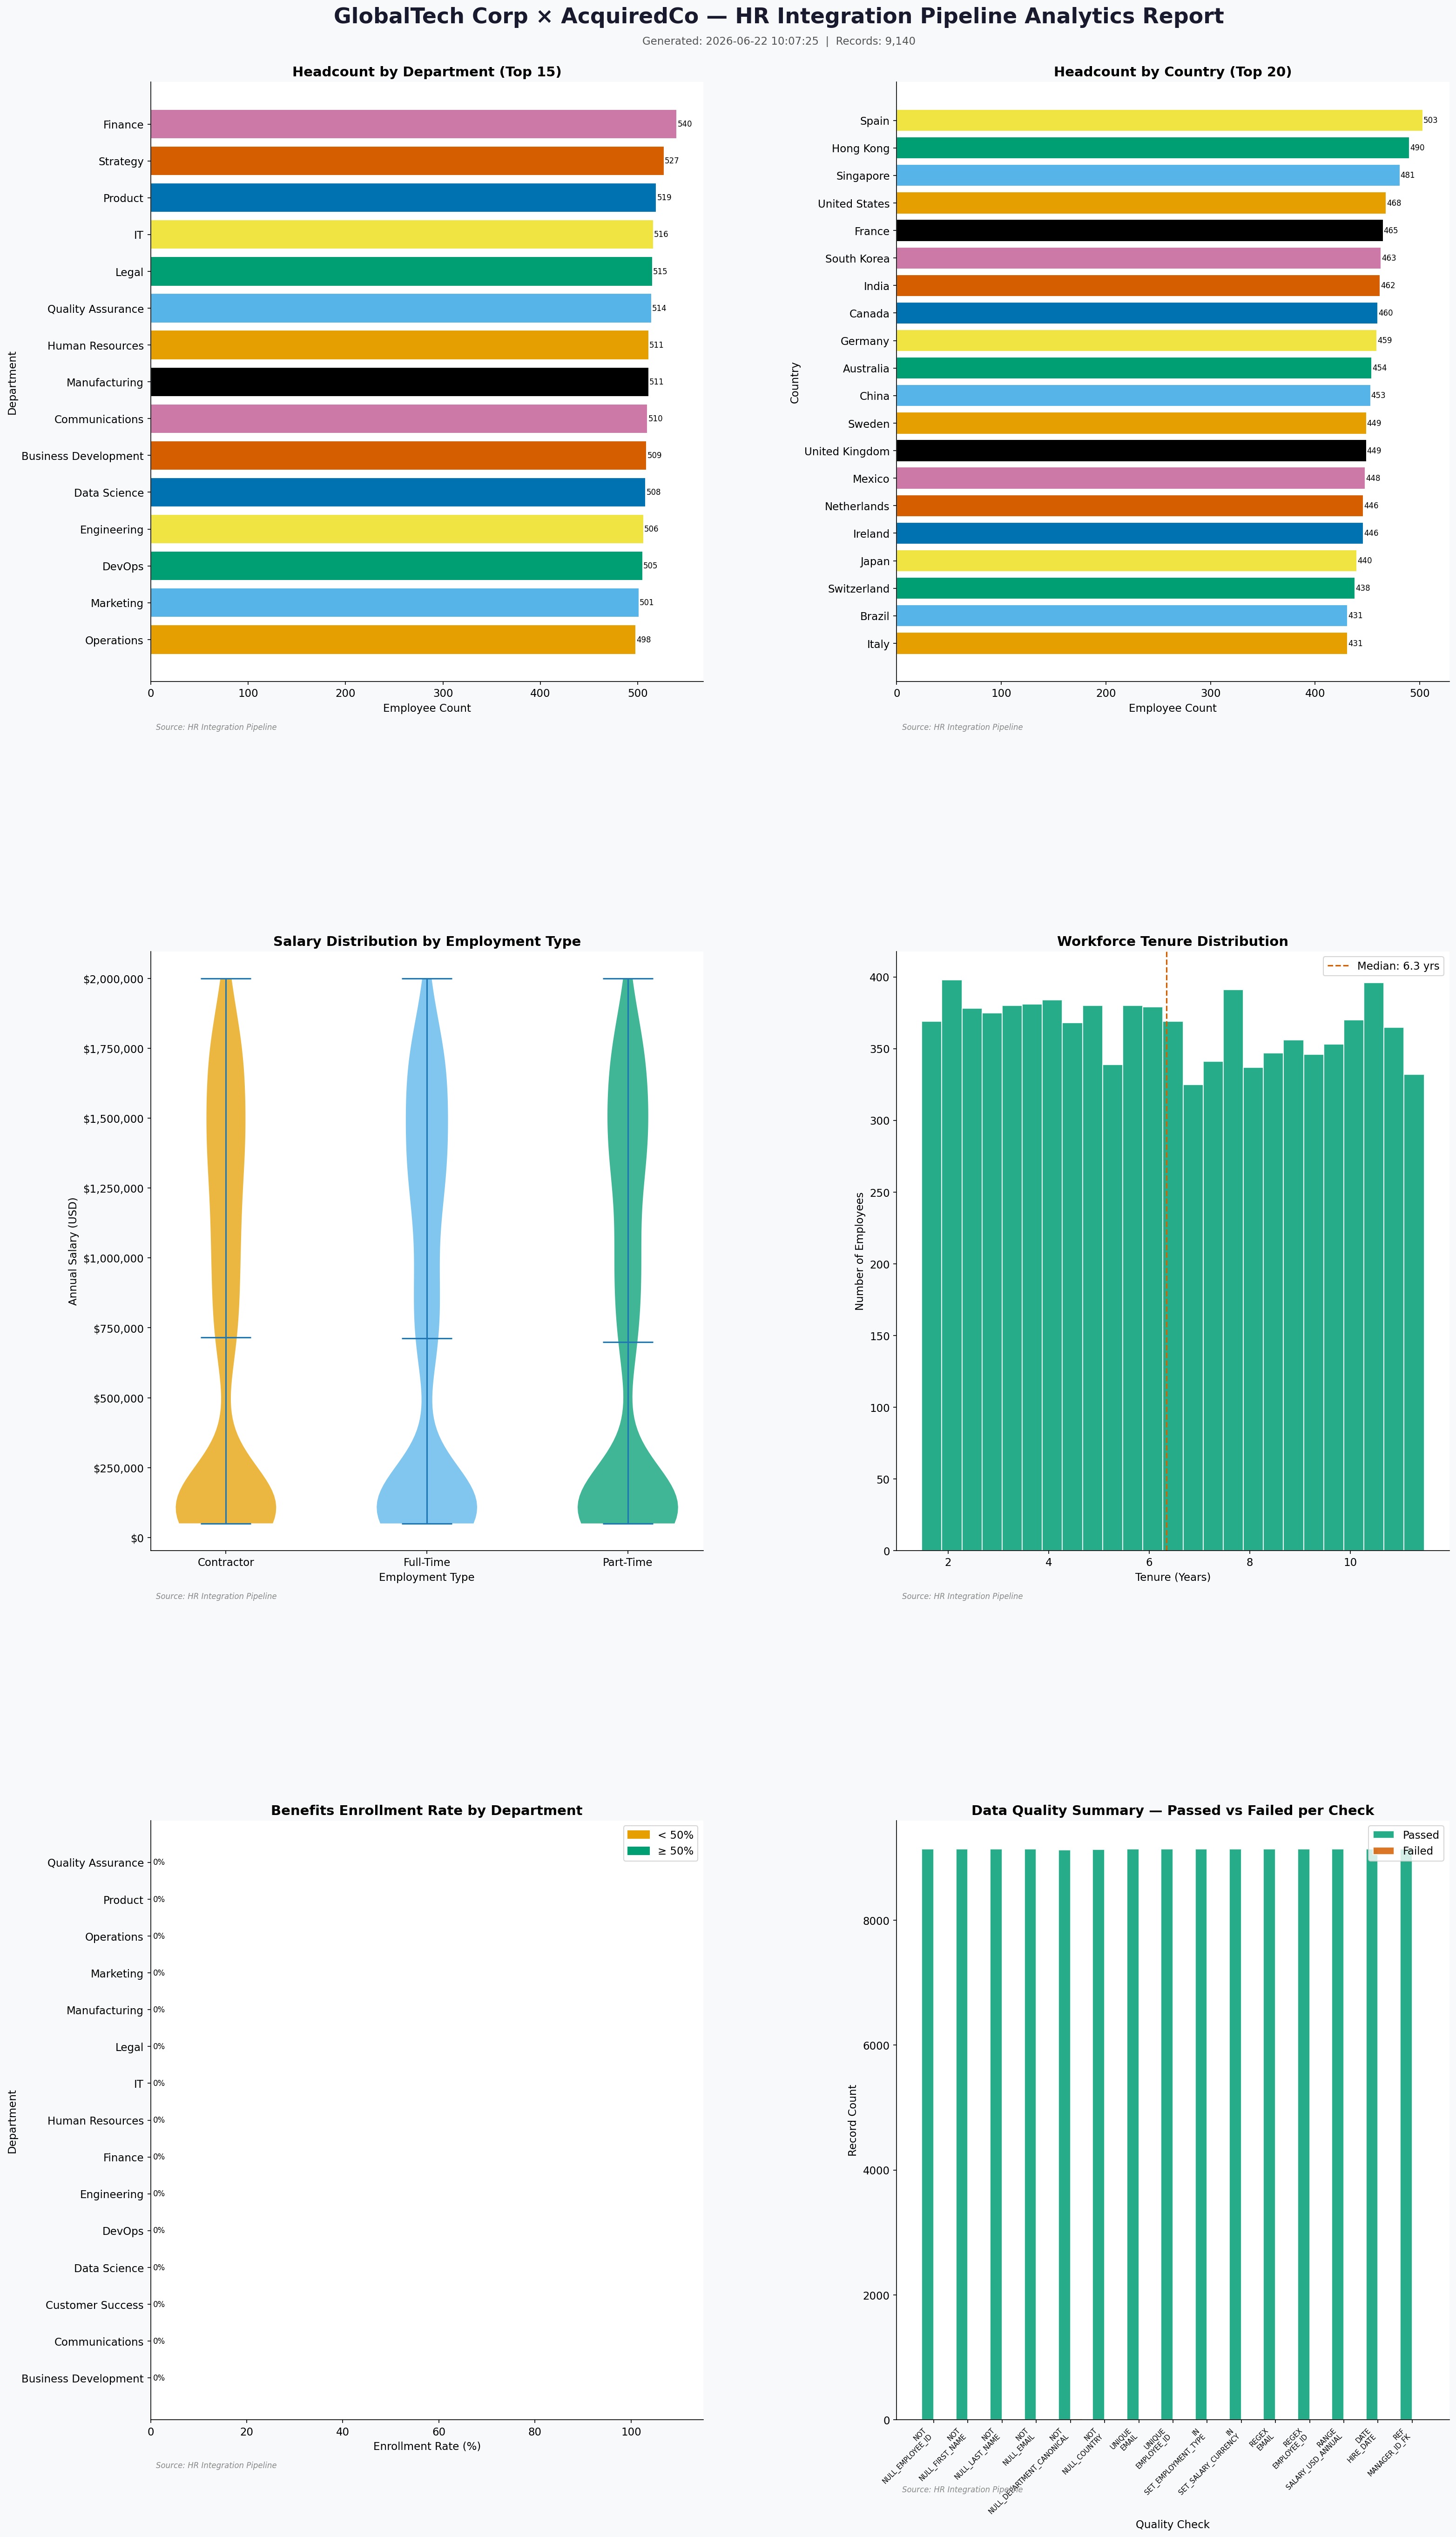


Full report saved to C:\Users\PatrickIradukunda\Desktop\Patrick-de-t-shaped-program-project-repo\sk-01-project\output\eda_report.png (300 DPI)


In [10]:
from datetime import datetime

fig = plt.figure(figsize=(24, 36), facecolor='#f8f9fa')
fig.suptitle('GlobalTech Corp × AcquiredCo — HR Integration Pipeline Analytics Report',
             fontsize=22, fontweight='bold', y=0.99, color='#1a1a2e')
fig.text(0.5, 0.975, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  |  Records: {len(df):,}",
         ha='center', fontsize=11, color='#555')
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35, top=0.96, bottom=0.03)
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'

ax1 = fig.add_subplot(gs[0, 0])
_barh(ax1, df[dept_col].value_counts().head(15).sort_values(),
      'Headcount by Department (Top 15)', ylabel='Department', fs=8, fontsize=14)

ax2 = fig.add_subplot(gs[0, 1])
_barh(ax2, df['country'].value_counts().head(20).sort_values(),
      'Headcount by Country (Top 20)', ylabel='Country', fs=8, fontsize=14)

ax3 = fig.add_subplot(gs[1, 0])
pf3 = df[['employment_type', 'salary_usd_annual']].dropna()
types3 = sorted(pf3['employment_type'].dropna().unique())
data3 = [pf3.loc[pf3['employment_type'] == t, 'salary_usd_annual'].values for t in types3]
if data3 and all(len(d) > 0 for d in data3):
    parts3 = ax3.violinplot(data3, positions=range(len(types3)), showmedians=True)
    for i, pc in enumerate(parts3['bodies']): pc.set_facecolor(PALETTE[i % len(PALETTE)]); pc.set_alpha(0.75)
ax3.set_xticks(range(len(types3))); ax3.set_xticklabels(types3)
ax3.set(ylabel='Annual Salary (USD)', xlabel='Employment Type')
ax3.set_title('Salary Distribution by Employment Type', fontsize=14, fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.spines[['top', 'right']].set_visible(False); _src(ax3)

ax4 = fig.add_subplot(gs[1, 1])
tenure = ((pd.Timestamp.today() - pd.to_datetime(df['hire_date'], errors='coerce')).dt.days / 365.25).dropna().clip(lower=0)
median = tenure.median()
ax4.hist(tenure, bins=25, color=PALETTE[2], edgecolor='white', alpha=0.85)
ax4.axvline(median, color=PALETTE[5], linestyle='--', linewidth=1.5, label=f'Median: {median:.1f} yrs')
ax4.legend(); ax4.set(xlabel='Tenure (Years)', ylabel='Number of Employees')
ax4.set_title('Workforce Tenure Distribution', fontsize=14, fontweight='bold')
ax4.spines[['top', 'right']].set_visible(False); _src(ax4)

ax5 = fig.add_subplot(gs[2, 0])
pf5 = df[[dept_col, 'benefits_enrolled']].dropna(subset=[dept_col]).copy()
pf5['benefits_enrolled'] = pf5['benefits_enrolled'].astype(bool)
_enroll_barh(ax5, pf5.groupby(dept_col)['benefits_enrolled'].mean().sort_values().head(15),
             'Benefits Enrollment Rate by Department', fs=8, fontsize=14)

ax6 = fig.add_subplot(gs[2, 1])
if not validation_report.empty:
    _quality_bar(ax6, validation_report, fontsize=14)
else:
    ax6.text(0.5, 0.5, 'No validation data available', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Data Quality Summary', fontsize=14, fontweight='bold')

out_path = OUTPUT_DIR / 'eda_report.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor()); plt.show()
print(f'\nFull report saved to {out_path} (300 DPI)')